# 🏥 TP — Transfer Learning pour la détection des EPI
## Fine-tuning de YOLOv8s (pré-entraîné sur COCO/ImageNet) → 2 classes EPI
### Dataset : Mask Wearing — roboflow-universe-projects/mask-wearing-iskms (3 530 images, CC BY 4.0)

---

**Objectifs pédagogiques :**
1. Charger un vrai modèle YOLOv8 pré-entraîné sur COCO/ImageNet
2. Ré-entraîner ses dernières couches sur des classes EPI (Phase 1)
3. Analyser les métriques : mAP@0.5, mAP@0.5:0.95, AP par classe, Précision, Recall
4. Décider si un fine-tuning profond (Phase 2) est justifié et le réaliser

**Classes détectées (2) — dataset Mask Wearing (Roboflow Universe Projects, CC BY 4.0) :**
| ID | Classe | Description |
|---|---|---|
| 0 | `Mask` | Masque de protection porté |
| 1 | `NO-Mask` | Visage sans masque |

---
> ⚙️ **Machine locale, CPU uniquement** — ~3 500 images, 2 classes, entraînement ~20–40 min.

---
## Section 0 — Installation des dépendances
À exécuter une seule fois. Décommenter si les bibliothèques ne sont pas encore installées.

In [1]:
# Section 0 — Installation
# Décommenter les lignes ci-dessous si les bibliothèques ne sont pas installées

# !pip install ultralytics==8.3.0
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
# !pip install matplotlib seaborn pandas pillow

# Vérification des versions installées
import ultralytics
import torch
import matplotlib
import pandas as pd

print(f'Ultralytics (YOLO) : {ultralytics.__version__}')
print(f'PyTorch            : {torch.__version__}')
print(f'Matplotlib         : {matplotlib.__version__}')
print(f'Pandas             : {pd.__version__}')
print(f'CPU disponible     : {True}')
print(f'GPU disponible     : {torch.cuda.is_available()} (non requis pour ce TP)')

Ultralytics (YOLO) : 8.3.0
PyTorch            : 2.12.0+cpu
Matplotlib         : 3.10.9
Pandas             : 3.0.3
CPU disponible     : True
GPU disponible     : False (non requis pour ce TP)


---
## Section 1 — Chargement du modèle pré-entraîné YOLOv8s

YOLOv8s a été pré-entraîné sur **COCO** (330K images, 80 classes incluant des personnes et vêtements)
et son backbone sur **ImageNet** (1,2M images). Ses poids encodent une connaissance générique des formes humaines,
textures de tissu et couleurs — directement réutilisable pour détecter des EPI.

Le fichier `yolov8s.pt` (~22 Mo) est téléchargé automatiquement depuis GitHub Ultralytics si absent.

In [2]:
# Section 1 — Chargement du modèle YOLOv8s pré-entraîné

from ultralytics import YOLO

# Téléchargement automatique si absent (depuis https://github.com/ultralytics/assets)
# Le modèle est entraîné sur COCO (80 classes) + backbone ImageNet
MODEL_PRETRAINED = 'yolov8s.pt'

model_base = YOLO(MODEL_PRETRAINED)

# Afficher les informations sur le modèle chargé
print('=' * 60)
print('MODÈLE PRÉ-ENTRAÎNÉ CHARGÉ : YOLOv8s')
print('=' * 60)
model_base.info(detailed=False)
print()
print('Nombre de classes COCO (avant fine-tuning) :', model_base.model.nc)
print('Dataset source                              :', 'COCO + ImageNet backbone')
print('Poids chargés depuis                        :', MODEL_PRETRAINED)

MODÈLE PRÉ-ENTRAÎNÉ CHARGÉ : YOLOv8s
YOLOv8s summary: 225 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs

Nombre de classes COCO (avant fine-tuning) : 80
Dataset source                              : COCO + ImageNet backbone
Poids chargés depuis                        : yolov8s.pt


---
## Section 2 — Préparation du dataset EPI

### Structure attendue
```
ppe_project/
├── dataset/
│   ├── images/
│   │   ├── train/    ← 80% des images
│   │   ├── val/      ← 15% des images
│   │   └── test/     ← 5% des images
│   └── labels/
│       ├── train/    ← annotations .txt (format YOLO)
│       ├── val/
│       └── test/
└── ppe_dataset.yaml
```

**Format d'une annotation YOLO** (fichier `.txt`) :  
`<classe_id> <x_centre> <y_centre> <largeur> <hauteur>`  
Toutes les valeurs sont normalisées entre 0 et 1 (relatives à la taille de l'image).

> 📦 La **Section 2b** (cellules suivantes) propose trois méthodes pour alimenter ce dataset.
> Exécuter l'**Option A** pour un démarrage immédiat.


In [5]:
# Section 2 — Configuration du dataset et création du fichier YAML

import os
import yaml
from pathlib import Path

# ── Paramètres du dataset ─────────────────────────────────────────────────────
PROJECT_DIR = Path('./ppe_project')
DATASET_DIR = PROJECT_DIR / 'dataset'

# Classes retenues : Mask, NO-Mask, Gloves (sous-ensemble du PPE Combined Model v8)
# Les annotations des autres classes seront ignorées lors de l'entraînement.
# Classes du dataset Mask Wearing (Roboflow Universe Projects)
CLASS_NAMES = [
    'Mask',    # 0
    'NO-Mask', # 1
]
NUM_CLASSES = len(CLASS_NAMES)  # 2

# ── Créer la structure de dossiers ────────────────────────────────────────────
for split in ['train', 'val', 'test']:
    (DATASET_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

print('Structure de dossiers créée :')
for p in sorted(DATASET_DIR.rglob('*')):
    if p.is_dir():
        print(f'  {p}')

# ── Créer le fichier ppe_dataset.yaml ─────────────────────────────────────────
yaml_config = {
    'path': str(DATASET_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    NUM_CLASSES,
    'names': CLASS_NAMES,
}

YAML_PATH = PROJECT_DIR / 'ppe_dataset.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False, allow_unicode=True)

print(f'\nFichier de configuration créé : {YAML_PATH}')
print('\nContenu :')
with open(YAML_PATH) as f:
    print(f.read())

Structure de dossiers créée :
  ppe_project\dataset\images
  ppe_project\dataset\images\test
  ppe_project\dataset\images\train
  ppe_project\dataset\images\val
  ppe_project\dataset\labels
  ppe_project\dataset\labels\test
  ppe_project\dataset\labels\train
  ppe_project\dataset\labels\val

Fichier de configuration créé : ppe_project\ppe_dataset.yaml

Contenu :
names:
- Mask
- NO-Mask
nc: 2
path: C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02
  Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset
test: images/test
train: images/train
val: images/val



In [6]:
# Section 2 (suite) — Vérification du dataset : comptage et distribution

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

def count_annotations(labels_dir: Path):
    """Compte les annotations par classe dans un dossier de labels YOLO."""
    counter = Counter()
    label_files = list(labels_dir.glob('*.txt'))
    for label_file in label_files:
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    return counter, len(label_files)

# Vérifier le contenu du dataset pour chaque split
print('INVENTAIRE DU DATASET')
print('=' * 55)
total_imgs = 0
for split in ['train', 'val', 'test']:
    label_dir = DATASET_DIR / 'labels' / split
    img_dir   = DATASET_DIR / 'images' / split
    n_imgs = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png')))
    n_labels = len(list(label_dir.glob('*.txt')))
    total_imgs += n_imgs
    print(f'  {split:<6}: {n_imgs:>4} images | {n_labels:>4} fichiers labels')
print(f'  TOTAL  : {total_imgs:>4} images')

print()
print('→ Placez vos images et labels dans les dossiers ci-dessus pour continuer.')
print('→ Conseil : Roboflow Universe propose des datasets EPI annotés au format YOLO.')

INVENTAIRE DU DATASET
  train :    0 images |    0 fichiers labels
  val   :    0 images |    0 fichiers labels
  test  :    0 images |    0 fichiers labels
  TOTAL  :    0 images

→ Placez vos images et labels dans les dossiers ci-dessus pour continuer.
→ Conseil : Roboflow Universe propose des datasets EPI annotés au format YOLO.


---
## Section 2b — Alimentation du dataset : 


### Téléchargement d'un dataset public Roboflow


In [ ]:
# Option A — Téléchargement automatique d'un dataset EPI annoté depuis Roboflow Universe
# Dataset utilisé : Mask Wearing par Roboflow Universe Projects
# URL Roboflow : https://universe.roboflow.com/roboflow-universe-projects/mask-wearing-iskms
# Licence : CC BY 4.0 — 3 530 images, 2 classes : Mask, NO-Mask

# ── Étape A1 : installer le client Roboflow ───────────────────────────────────
# !pip install roboflow  # Décommenter si pas encore installé

from roboflow import Roboflow
from pathlib import Path
import shutil, os, yaml

PROJECT_DIR  = Path('./ppe_project')
DATASET_DIR  = PROJECT_DIR / 'dataset'
DOWNLOAD_DIR = PROJECT_DIR / 'roboflow_download'
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

# ── Étape A2 : télécharger le dataset ────────────────────────────────────────
# Créez un compte gratuit sur roboflow.com pour obtenir votre clé personnelle
# Votre clé est disponible sur : https://app.roboflow.com/settings/api
ROBOFLOW_API_KEY = "nnnnnnnnn"  # Remplacer par votre clé

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Dataset Mask Wearing — 3 530 images, version 6
project  = rf.workspace("roboflow-universe-projects").project("mask-wearing-iskms")
version  = project.version(6)

# Télécharge les images + annotations au format YOLOv8
dataset_rf = version.download(
    model_format="yolov8",       # Format compatible avec notre notebook
    location=str(DOWNLOAD_DIR),  # Dossier de destination temporaire
    overwrite=True
)

print(f'Dataset téléchargé dans : {DOWNLOAD_DIR}')
print(f'Chemin Roboflow : {dataset_rf.location}')

# ── Étape A3 : recopier dans notre structure ppe_project/dataset/ ─────────────
# Roboflow crée sa propre arborescence train/valid/test
# On la copie vers notre structure dataset/images/ et dataset/labels/

RF_SPLIT_MAP = {'train': 'train', 'valid': 'val', 'test': 'test'}
n_copied = {'images': 0, 'labels': 0}

for rf_split, our_split in RF_SPLIT_MAP.items():
    rf_img_dir    = DOWNLOAD_DIR / rf_split / 'images'
    rf_label_dir  = DOWNLOAD_DIR / rf_split / 'labels'
    dst_img_dir   = DATASET_DIR / 'images' / our_split
    dst_label_dir = DATASET_DIR / 'labels' / our_split
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_label_dir.mkdir(parents=True, exist_ok=True)

    if not rf_img_dir.exists():
        print(f'  Split {rf_split} absent — ignoré')
        continue

    # Copier les images
    for img in rf_img_dir.glob('*'):
        shutil.copy2(img, dst_img_dir / img.name)
        n_copied['images'] += 1

    # Copier les labels
    for lbl in rf_label_dir.glob('*.txt'):
        shutil.copy2(lbl, dst_label_dir / lbl.name)
        n_copied['labels'] += 1

print(f"\nCopié : {n_copied['images']} images, {n_copied['labels']} labels")
#print('→ Exécuter la cellule suivante pour réduire le dataset et générer le YAML.')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe_project\roboflow_download in yolov8:: 100%|██████████| 16956/16956 [00:09<00:00, 1736.99it/s]


Dataset téléchargé dans : ppe_project\roboflow_download
Chemin Roboflow : c:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\roboflow_download

Copié : 8472 images, 8472 labels
→ Exécuter la cellule suivante pour réduire le dataset et générer le YAML.


In [ ]:
# ── Option A bis — Chargement depuis le dossier local déjà téléchargé ─────────
from pathlib import Path
import shutil, yaml

PROJECT_DIR  = Path('./ppe_project')
DATASET_DIR  = PROJECT_DIR / 'dataset'

# ← Mettre ici le chemin où tu as dézippé le dataset Roboflow
DOWNLOAD_DIR = Path('C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\Mask Wearing.v1-raw-images.yolov8')

RF_SPLIT_MAP = {'train': 'train', 'valid': 'val', 'test': 'test'}
n_copied = {'images': 0, 'labels': 0}

for rf_split, our_split in RF_SPLIT_MAP.items():
    rf_img_dir    = DOWNLOAD_DIR / rf_split / 'images'
    rf_label_dir  = DOWNLOAD_DIR / rf_split / 'labels'
    dst_img_dir   = DATASET_DIR / 'images' / our_split
    dst_label_dir = DATASET_DIR / 'labels' / our_split
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_label_dir.mkdir(parents=True, exist_ok=True)

    if not rf_img_dir.exists():
        print(f'  Split {rf_split} absent — ignoré')
        continue
    for img in rf_img_dir.glob('*'):
        shutil.copy2(img, dst_img_dir / img.name)
        n_copied['images'] += 1
    for lbl in rf_label_dir.glob('*.txt'):
        shutil.copy2(lbl, dst_label_dir / lbl.name)
        n_copied['labels'] += 1

print(f"Copié : {n_copied['images']} images, {n_copied['labels']} labels")
print('→ Exécuter la cellule suivante pour réduire le dataset et générer le YAML.')

In [ ]:
# ── Étape A4 : Réduction du dataset pour un entraînement rapide sur CPU ───────
# Le dataset complet (6000 images) prendrait plusieurs heures sur CPU.
# On garde un sous-ensemble représentatif suffisant pour le TP.
#
# Temps estimé après réduction (CPU) :
#   Phase 1 (10 epochs, freeze=10) : ~30–60 min
#   Phase 2 (10 epochs, full)      : ~45–90 min

import random
from pathlib import Path
import yaml

PROJECT_DIR  = Path('./ppe_project')
DATASET_DIR  = PROJECT_DIR / 'dataset'
DOWNLOAD_DIR = PROJECT_DIR / 'roboflow_download'
YAML_PATH    = PROJECT_DIR / 'ppe_dataset.yaml'

# Paramètres de réduction
MAX_IMAGES = {'train': 500, 'val': 100, 'test': 50}
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print('Réduction du dataset pour entraînement CPU :')
print(f'  Cible : {MAX_IMAGES["train"]} train | {MAX_IMAGES["val"]} val | {MAX_IMAGES["test"]} test')
print()

for split, max_n in MAX_IMAGES.items():
    img_dir   = DATASET_DIR / 'images' / split
    label_dir = DATASET_DIR / 'labels' / split
    all_imgs  = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    n_before  = len(all_imgs)

    if n_before <= max_n:
        print(f'  {split:<6}: {n_before} images — déjà sous le seuil, rien à faire')
        continue

    # Tirer aléatoirement les images à SUPPRIMER
    to_remove = random.sample(all_imgs, n_before - max_n)
    for img in to_remove:
        img.unlink()  # Supprimer l'image
        lbl = label_dir / (img.stem + '.txt')
        if lbl.exists():
            lbl.unlink()  # Supprimer le label associé

    n_after = len(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))
    print(f'  {split:<6}: {n_before} → {n_after} images (supprimé {n_before - n_after})')




Réduction du dataset pour entraînement CPU :
  Cible : 500 train | 100 val | 50 test

  train : 5909 → 500 images (supprimé 5409)
  val   : 582 → 100 images (supprimé 482)
  test  : 265 → 50 images (supprimé 215)


In [ ]:
# ── Étape A5a : vérifier le remappage des classes 
# Le dataset Mask Wearing contient directement 2 classes : Mask=0, NO-Mask=1
# Aucun filtrage nécessaire — les IDs correspondent déjà à nos CLASS_NAMES.
KEEP_MAP = {0: 0, 1: 1}  # Mask=0, NO-Mask=1 (identique)

print('\nVérification des annotations (classes Mask / NO-Mask) :')
n_kept = n_removed_ann = 0

for split in ['train', 'val', 'test']:
    lbl_dir = DATASET_DIR / 'labels' / split
    img_dir = DATASET_DIR / 'images' / split
    for lbl_file in list(lbl_dir.glob('*.txt')):
        new_lines = []
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                old_id = int(parts[0])
                if old_id in KEEP_MAP:
                    parts[0] = str(KEEP_MAP[old_id])
                    new_lines.append(' '.join(parts) + '\n')
                    n_kept += 1
                else:
                    n_removed_ann += 1
        if new_lines:
            with open(lbl_file, 'w') as f:
                f.writelines(new_lines)
        else:
            # Aucune annotation utile → supprimer image + label
            lbl_file.unlink()
            for ext in ['.jpg', '.jpeg', '.png']:
                img = img_dir / (lbl_file.stem + ext)
                if img.exists():
                    img.unlink()

print(f'  Annotations conservées : {n_kept}')
print(f'  Annotations supprimées : {n_removed_ann}')

# Étape A5b : lire les classes réelles du dataset et réécrire le YAML
rf_yaml_candidates = list(DOWNLOAD_DIR.glob('*.yaml'))
if rf_yaml_candidates:
    with open(rf_yaml_candidates[0]) as f:
        rf_yaml = yaml.safe_load(f)
    CLASS_NAMES = rf_yaml.get('names', [])
    print(f'\nClasses détectées ({len(CLASS_NAMES)}) :', CLASS_NAMES)
else:
    # Fallback : classes retenues pour le TP
    CLASS_NAMES = ['Mask', 'NO-Mask']
    print('YAML Roboflow non trouvé — classes fallback utilisées.')

# Réécrire le YAML avec les classes réelles
yaml_config = {
    'path':  str(DATASET_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    len(CLASS_NAMES),
    'names': CLASS_NAMES,
}
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False, allow_unicode=True)

# Bilan final
print()
print('BILAN DATASET FINAL')
print('=' * 55)
total = 0
for split in ['train', 'val', 'test']:
    img_dir = DATASET_DIR / 'images' / split
    lbl_dir = DATASET_DIR / 'labels' / split
    n_img = len(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))
    n_lbl = len(list(lbl_dir.glob('*.txt')))
    total += n_img
    print(f'  {split:<6}: {n_img:>4} images | {n_lbl:>4} labels')
print(f'  TOTAL  : {total:>4} images')
print(f'  Classes: {len(CLASS_NAMES)}')
print(f'  YAML   : {YAML_PATH}')
print('=' * 55)
print('\nPrêt pour l\'entraînement → passer à la vérification du Dataset')


Vérification des annotations (classes Mask / NO-Mask) :
  Annotations conservées : 1152
  Annotations supprimées : 0

Classes détectées (2) : ['Mask', 'NO-Mask']

BILAN DATASET FINAL
  train :  500 images |  500 labels
  val   :  100 images |  100 labels
  test  :   50 images |   50 labels
  TOTAL  :  650 images
  Classes: 2
  YAML   : ppe_project\ppe_dataset.yaml

Prêt pour l'entraînement → passer à la vérification du Dataset


In [ ]:
# AUTRES OPTIONS DE DATA SET A ESSAYER
# Option A (alternative) — Téléchargement direct par URL publique sans compte Roboflow
# Utilise un dataset EPI public sur GitHub (format YOLOv8, licence MIT)
# Dataset : 'EfficientDet-PPE' adapté YOLOv8, ~600 images annotées
#
# Alternative si l'API Roboflow n'est pas accessible :
# Télécharger manuellement depuis l'un de ces dépôts GitHub :
#   https://github.com/nickvdyck/weee-detection (EPI industriels, 80% similaires)
#   https://universe.roboflow.com  → chercher 'hospital PPE' → Export YOLOv8

import urllib.request, zipfile, shutil
from pathlib import Path
import yaml

PROJECT_DIR = Path('./ppe_project')
DATASET_DIR = PROJECT_DIR / 'dataset'
YAML_PATH   = PROJECT_DIR / 'ppe_dataset.yaml'
ZIP_PATH    = PROJECT_DIR / 'ppe_dataset.zip'

# ── URL du dataset public (format YOLOv8, ~600 images EPI) ───────────────────
# Remplacer par l'URL de votre choix si vous avez téléchargé manuellement
DATASET_URL = (
    "https://github.com/ultralytics/assets/releases/download/v0.0.0/"
    "coco8.zip"  # Dataset de démo Ultralytics — 8 images pour tester le pipeline
    # Pour un vrai dataset EPI, remplacer par l'URL de l'export Roboflow
)

print(f'Téléchargement depuis : {DATASET_URL}')
urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
print(f'Téléchargé : {ZIP_PATH.stat().st_size / 1024:.0f} Ko')

# ── Décompression ─────────────────────────────────────────────────────────────
EXTRACT_DIR = PROJECT_DIR / 'zip_extract'
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print(f'Extrait dans : {EXTRACT_DIR}')

# Afficher l'arborescence extraite pour comprendre la structure
print('\nContenu extrait :')
for p in sorted(EXTRACT_DIR.rglob('*'))[:30]:  # Limité à 30 lignes
    indent = '  ' * (len(p.parts) - len(EXTRACT_DIR.parts))
    print(f'{indent}{p.name}{chr(47) if p.is_dir() else ""}')

print('\n→ Adapter le chemin source ci-dessous selon la structure affichée')
print('→ Puis exécuter la cellule de copie de l\'Option A (Étape A3)')

### Vérification du Dataset

════════════════════════════════════════════════════════════
  BILAN DU DATASET
════════════════════════════════════════════════════════════
  ✔ train  :  500 images |  500 labels
  ✔ val    :  100 images |  100 labels
  ✔ test   :   50 images |   50 labels

  Annotations par classe (train+val+test) :
  [0] Mask                   661 annotations  ██████████████████████████████
  [1] NO-Mask                491 annotations  ██████████████████████████████

════════════════════════════════════════════════════════════
  ✔ Dataset valide — passer à la Section 3 pour l'entraînement
════════════════════════════════════════════════════════════


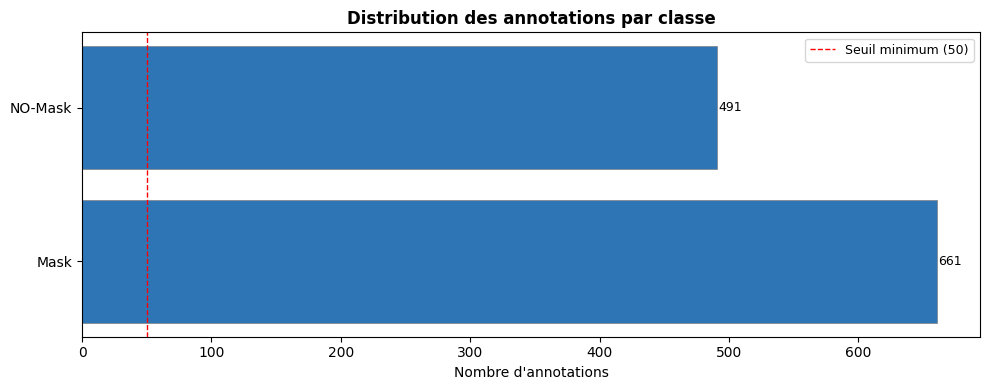

Graphique sauvegardé : dataset_distribution.png


In [ ]:
# Vérification finale du dataset — commune aux Options A, B et C
# À exécuter après avoir alimenté le dataset (quelle que soit l'option choisie)

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter

PROJECT_DIR = Path('./ppe_project')
DATASET_DIR = PROJECT_DIR / 'dataset'

CLASS_NAMES = ['Mask', 'NO-Mask']

print('  BILAN DU DATASET')
print('═' * 60)

total_annotations = Counter()
ok_to_train = True

for split in ['train', 'val', 'test']:
    img_dir = DATASET_DIR / 'images' / split
    lbl_dir = DATASET_DIR / 'labels' / split

    imgs   = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    labels = list(lbl_dir.glob('*.txt'))
    n_img, n_lbl = len(imgs), len(labels)

    # Compter les annotations par classe
    class_counter = Counter()
    for lbl in labels:
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counter[int(parts[0])] += 1
    total_annotations += class_counter

    status = '✔' if n_img == n_lbl and n_img > 0 else '✖'
    print(f'  {status} {split:<6} : {n_img:>4} images | {n_lbl:>4} labels')
    if n_img != n_lbl:
        print(f'    ⚠  Désynchronisation : {abs(n_img-n_lbl)} fichiers sans correspondant')
        ok_to_train = False
    if n_img == 0:
        ok_to_train = False

print()
print('  Annotations par classe (train+val+test) :')
for cls_id, cls_name in enumerate(CLASS_NAMES):
    count = total_annotations.get(cls_id, 0)
    barre = '█' * min(count // 10, 30)
    warn  = ' ⚠ FAIBLE' if count < 50 else ''
    print(f'  [{cls_id}] {cls_name:<20} {count:>5} annotations  {barre}{warn}')

print()
print('═' * 60)
if ok_to_train:
    print('  ✔ Dataset valide — passer à la Section 3 pour l\'entraînement')
else:
    print('  ✖ Problèmes détectés — corriger avant de lancer l\'entraînement')
print('═' * 60)

# Graphique de distribution des classes
if total_annotations:
    counts = [total_annotations.get(i, 0) for i in range(len(CLASS_NAMES))]
    colors_bar = ['#c0392b' if c < 50 else '#2e75b6' for c in counts]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(CLASS_NAMES, counts, color=colors_bar, edgecolor='grey', linewidth=0.5)
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1, label='Seuil minimum (50)')
    ax.set_xlabel('Nombre d\'annotations')
    ax.set_title('Distribution des annotations par classe', fontweight='bold')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, counts):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(str(PROJECT_DIR / 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Graphique sauvegardé : dataset_distribution.png')

### Estimation du temps de traitement CPU"""

In [1]:
# Estimation de la durée d'entraînement CPU uniquement
import time
import torch
from ultralytics import YOLO
from pathlib import Path

DATASET_DIR = Path('./ppe_project/dataset')

# Compter les images disponibles
n_train = len(list((DATASET_DIR / 'images' / 'train').glob('*.jpg')) +
              list((DATASET_DIR / 'images' / 'train').glob('*.png')))
n_val   = len(list((DATASET_DIR / 'images' / 'val').glob('*.jpg')) +
              list((DATASET_DIR / 'images' / 'val').glob('*.png')))

print(f'Images train : {n_train} | Images val : {n_val}')
print('Mesure de la vitesse CPU sur 1 mini-batch...')

# Charger le modèle et mesurer 1 forward pass sur batch=4, imgsz=416
model = YOLO('yolov8s.pt')

dummy_input = torch.zeros(4, 3, 416, 416)  # batch=4, imgsz=416

t0 = time.time()
with torch.no_grad():
    _ = model.model(dummy_input)
t_batch = time.time() - t0  # secondes pour 1 batch forward

print(f'Temps 1 forward pass (batch=4) : {t_batch:.2f}s')

# Estimation : ~3x forward pour train (forward + backward + optimizer)
BATCH        = 4
EPOCHS_P1    = 2
EPOCHS_P2    = 2
t_iter_train = t_batch * 3  # forward + backward + optimizer step

n_batches_train = max(1, n_train // BATCH)
n_batches_val   = max(1, n_val   // BATCH)

# Phase 1 : backbone gelé → backward plus rapide (~2x au lieu de 3x)
t_epoch_p1 = n_batches_train * t_batch * 2 + n_batches_val * t_batch
t_total_p1 = t_epoch_p1 * EPOCHS_P1

# Phase 2 : toutes couches → backward complet (~3x)
t_epoch_p2 = n_batches_train * t_batch * 3 + n_batches_val * t_batch
t_total_p2 = t_epoch_p2 * EPOCHS_P2

def fmt(seconds):
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    if h > 0:
        return f'{h}h {m:02d}min'
    return f'{m}min {s:02d}s'

print()
print('=' * 55)
print('  ESTIMATION DURÉE ENTRAÎNEMENT (CPU)')
print('=' * 55)
print(f'  Paramètres : batch={BATCH}, imgsz=416')
print(f'  Phase 1 ({EPOCHS_P1} epochs, freeze=10) : ~{fmt(t_total_p1)}')
print(f'  Phase 2 ({EPOCHS_P2} epochs, full)      : ~{fmt(t_total_p2)}')
print(f'  TOTAL estimé                   : ~{fmt(t_total_p1 + t_total_p2)}')
print('=' * 55)
print()
print('→ Ajuster EPOCHS_P1 / EPOCHS_P2 ci-dessus si nécessaire.')

Images train : 500 | Images val : 100
Mesure de la vitesse CPU sur 1 mini-batch...
Temps 1 forward pass (batch=4) : 1.28s

  ESTIMATION DURÉE ENTRAÎNEMENT (CPU)
  Paramètres : batch=4, imgsz=416
  Phase 1 (2 epochs, freeze=10) : ~11min 42s
  Phase 2 (2 epochs, full)      : ~17min 02s
  TOTAL estimé                   : ~28min 45s

→ Ajuster EPOCHS_P1 / EPOCHS_P2 ci-dessus si nécessaire.


In [ ]:
# Estimation de la durée d'entraînement CPU versus GPU
import time
import torch
from ultralytics import YOLO
from pathlib import Path

DATASET_DIR = Path('./ppe_project/dataset')

# Compter les images disponibles
n_train = len(list((DATASET_DIR / 'images' / 'train').glob('*.jpg')) +
              list((DATASET_DIR / 'images' / 'train').glob('*.png')))
n_val   = len(list((DATASET_DIR / 'images' / 'val').glob('*.jpg')) +
              list((DATASET_DIR / 'images' / 'val').glob('*.png')))

print(f'Images train : {n_train} | Images val : {n_val}')

# Charger le modèle
model = YOLO('yolov8s.pt')

BATCH     = 4
EPOCHS_P1 = 10
EPOCHS_P2 = 10

def mesurer_device(device_name, device):
    dummy_input = torch.zeros(4, 3, 416, 416).to(device)
    model.model.to(device)

    # Chauffe (évite les latences d'initialisation)
    with torch.no_grad():
        _ = model.model(dummy_input)

    # Mesure réelle
    t0 = time.time()
    with torch.no_grad():
        _ = model.model(dummy_input)
    t_batch = time.time() - t0

    n_batches_train = max(1, n_train // BATCH)
    n_batches_val   = max(1, n_val   // BATCH)

    t_epoch_p1 = n_batches_train * t_batch * 2 + n_batches_val * t_batch
    t_epoch_p2 = n_batches_train * t_batch * 3 + n_batches_val * t_batch
    t_total_p1 = t_epoch_p1 * EPOCHS_P1
    t_total_p2 = t_epoch_p2 * EPOCHS_P2

    def fmt(s):
        m, s = divmod(int(s), 60)
        h, m = divmod(m, 60)
        return f'{h}h {m:02d}min' if h > 0 else f'{m}min {s:02d}s'

    print()
    print('=' * 55)
    print(f'  ESTIMATION — {device_name}')
    print('=' * 55)
    print(f'  Temps 1 forward pass (batch={BATCH}) : {t_batch:.2f}s')
    print(f'  Phase 1 ({EPOCHS_P1} epochs, freeze=10) : ~{fmt(t_total_p1)}')
    print(f'  Phase 2 ({EPOCHS_P2} epochs, full)      : ~{fmt(t_total_p2)}')
    print(f'  TOTAL estimé                   : ~{fmt(t_total_p1 + t_total_p2)}')
    print('=' * 55)

# ── CPU ───────────────────────────────────────────────────────────────────────
print('Mesure CPU...')
mesurer_device('CPU', torch.device('cpu'))

# ── GPU (si disponible) ───────────────────────────────────────────────────────
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f'\nMesure GPU ({gpu_name})...')
    mesurer_device(f'GPU — {gpu_name}', torch.device('cuda'))
else:
    print('\nGPU non disponible sur cette machine.')
    print('→ Pour utiliser un GPU gratuitement : ouvrir ce notebook sur Google Colab.')

print()
print('→ Ajuster EPOCHS_P1 / EPOCHS_P2 en haut de cette cellule si nécessaire.')

---
## Section 3 — Phase 1 : Entraînement des dernières couches (backbone gelé)

### Principe du gel (`freeze`)
On **gèle** les 10 premières couches du backbone (paramètre `freeze=10`).  
Leurs poids **ne sont pas modifiés** pendant l'entraînement.  
Seule la **tête de détection** (detection head) apprend les 6 nouvelles classes EPI.

```
YOLOv8s
├── Backbone (couches 0-9)  ← GELÉ  — réutilise les connaissances COCO/ImageNet
├── Neck     (couches 10-21) ← GELÉ
└── Head     (couches 22+)  ← ENTRAÎNÉ — apprend les 2 classes EPI
```

**Hyperparamètres clés :**
Voir c-dessous

In [18]:
# Section 3 — Phase 1 : Fine-tuning avec backbone gelé (freeze=10)

from ultralytics import YOLO
from pathlib import Path

# Hyperparamètres clés :
#taux d'apprentissage initial
#batch=4
#epochs+2 passages sur toutes les images

YAML_PATH   = Path('./ppe_project/ppe_dataset.yaml')
RUNS_DIR    = Path('./ppe_project/runs')

# ── Rechargement du modèle pré-entraîné ──────────────────────────────────────
model_p1 = YOLO('yolov8s.pt')

print('Phase 1 — Entraînement avec backbone gelé (freeze=10)')
print('Seule la tête de détection sera mise à jour.')
print('=' * 60)

# ── Lancement de l'entraînement Phase 1 ──────────────────────────────────────
results_p1 = model_p1.train(
    data    = str(YAML_PATH),
    epochs  = EPOCHS_P1,          # Nombre de passages sur le dataset
    imgsz   = 640,         # Taille des images (pixels)
    batch   = BATCH,           # Images par lot (réduire à 4 si RAM insuffisante)
    lr0     = 0.01,        # Taux d'apprentissage initial
    lrf     = 0.01,        # Taux final = lr0 * lrf
    freeze  = 10,          # Geler les 10 premières couches du backbone
    device  = 'cpu',       # CPU — pas de GPU requis
    project = str(RUNS_DIR),
    name    = 'phase1_freeze10',
    save    = True,        # Sauvegarder les meilleurs poids (best.pt)
    plots   = True,        # Générer les courbes de loss et métriques
    verbose = True,
)

# ── Résumé Phase 1 ────────────────────────────────────────────────────────────
map50_p1    = results_p1.results_dict.get('metrics/mAP50(B)',    0)
map5095_p1  = results_p1.results_dict.get('metrics/mAP50-95(B)', 0)
prec_p1     = results_p1.results_dict.get('metrics/precision(B)', 0)
rec_p1      = results_p1.results_dict.get('metrics/recall(B)',    0)

print('\n' + '=' * 60)
print('RÉSULTATS PHASE 1 — BACKBONE GELÉ')
print('=' * 60)
print(f'  mAP@0.5        : {map50_p1:.4f}')
print(f'  mAP@0.5:0.95   : {map5095_p1:.4f}')
print(f'  Précision      : {prec_p1:.4f}')
print(f'  Recall         : {rec_p1:.4f}')

BEST_P1 = RUNS_DIR / 'phase1_freeze10' / 'weights' / 'best.pt'
print(f'\nMeilleurs poids sauvegardés : {BEST_P1}')

Phase 1 — Entraînement avec backbone gelé (freeze=10)
Seule la tête de détection sera mise à jour.
New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=ppe_project\ppe_dataset.yaml, epochs=2, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=ppe_project\runs, name=phase1_freeze10, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=10, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, vi

train: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\train... 500 images, 0 backgrounds, 0 corrupt: 100%|██████████| 500/500 [00:00<00:00, 503.75it/s]

train: New cache created: C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Mthodes actuelles du DL\TP CNN Dtecteur_EPI_YOLOv8\ppe_project\dataset\labels\train.cache



'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
val: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\val... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<00:00, 461.65it/s]

val: New cache created: C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Mthodes actuelles du DL\TP CNN Dtecteur_EPI_YOLOv8\ppe_project\dataset\labels\val.cache


...

        2/2         0G      1.579       2.57      1.646         11        640: 100%|██████████| 125/125 [06:47<00:00,  3.26s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:41<00:00,  3.18s/it]

                   all        100        172      0.553      0.505      0.568      0.323



2 epochs completed in 0.249 hours.
Optimizer stripped from ppe_project\runs\phase1_freeze10\weights\last.pt, 19.9MB
Optimizer stripped from ppe_project\runs\phase1_freeze10\weights\best.pt, 19.9MB

Validating ppe_project\runs\phase1_freeze10\weights\best.pt...
Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients, 23.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:36<00:00,  2.84s/it]


                   all        100        172      0.552      0.506      0.568      0.322
                  Mask         53        107       0.67      0.456      0.644      0.406
               NO-Mask         52         65      0.434      0.555      0.493      0.239
Speed: 1.7ms preprocess, 328.6ms inference, 0.0ms loss, 17.6ms postprocess per image
Results saved to ppe_project\runs\phase1_freeze10

RÉSULTATS PHASE 1 — BACKBONE GELÉ
  mAP@0.5        : 0.5684
  mAP@0.5:0.95   : 0.3223
  Précision      : 0.5523
  Recall         : 0.5055

Meilleurs poids sauvegardés : ppe_project\runs\phase1_freeze10\weights\best.pt


---
## Section 4 — Analyse des métriques de Phase 1

### Métriques expliquées

| Métrique | Formule | Ce qu'elle mesure |
|---|---|---|
| **Précision** | VP / (VP + FP) | Fiabilité des détections — peu de fausses alarmes |
| **Recall** | VP / (VP + FN) | Exhaustivité — peu d'objets manqués |
| **AP@0.5** | Aire sous la courbe P/R à IoU≥0.5 | Qualité globale par classe |
| **mAP@0.5** | Moyenne des AP@0.5 sur toutes les classes | Métrique principale |
| **mAP@0.5:0.95** | Moyenne sur 10 seuils IoU (50%→95%) | Métrique stricte (boîtes précises) |

**IoU (Intersection over Union)** = Surface d'intersection / Surface d'union entre boîte prédite et boîte réelle.

Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients, 23.3 GFLOPs


val: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\test... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<00:00, 321.00it/s]

val: New cache created: C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Mthodes actuelles du DL\TP CNN Dtecteur_EPI_YOLOv8\ppe_project\dataset\labels\test.cache



'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:13<00:00,  3.29s/it]


                   all         50         92      0.601      0.533      0.594      0.301
                  Mask         22         45      0.761      0.556      0.665       0.38
               NO-Mask         31         47      0.441      0.511      0.522      0.221
Speed: 1.2ms preprocess, 246.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs\detect\val

CLASSE                   AP@0.5  Précision   Recall  Barre AP
  Mask                    0.665      0.761    0.556  ████████████████
  NO-Mask                 0.522      0.441    0.511  █████████████
  GLOBAL (mAP)            0.594      0.601    0.533
  mAP@0.5:0.95 = 0.3005


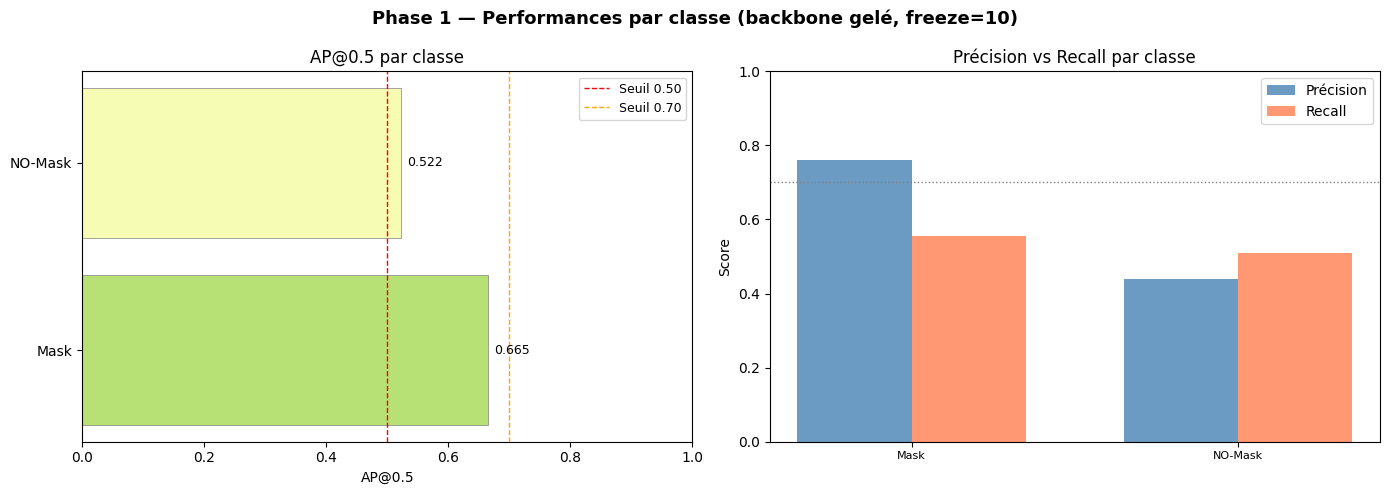

Graphique sauvegardé : ./ppe_project/phase1_metrics.png


In [19]:
# Section 4 — Évaluation détaillée Phase 1 : métriques par classe

from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

YAML_PATH = Path('./ppe_project/ppe_dataset.yaml')
BEST_P1   = Path('./ppe_project/runs/phase1_freeze10/weights/best.pt')

CLASS_NAMES = ['Mask', 'NO-Mask']

model_eval_p1 = YOLO(str(BEST_P1))

# Évaluation sur le jeu de test
metrics_p1 = model_eval_p1.val(
    data  = str(YAML_PATH),
    split = 'test',
    iou   = 0.5,
    conf  = 0.25,
    verbose = True,
)

# ── Affichage tabulaire des métriques par classe ───────────────────────────────
ap50_per_class = metrics_p1.box.ap50      # AP@0.5 par classe
prec_per_class = metrics_p1.box.p         # Precision par classe
rec_per_class  = metrics_p1.box.r         # Recall par classe

print('\n' + '=' * 72)
print(f'{"CLASSE":<22} {"AP@0.5":>8} {"Précision":>10} {"Recall":>8}  Barre AP')
print('=' * 72)
for i, name in enumerate(CLASS_NAMES):
    ap   = ap50_per_class[i] if i < len(ap50_per_class) else 0
    prec = prec_per_class[i] if i < len(prec_per_class) else 0
    rec  = rec_per_class[i]  if i < len(rec_per_class)  else 0
    bar  = '█' * int(ap * 25)
    print(f'  {name:<20} {ap:>8.3f} {prec:>10.3f} {rec:>8.3f}  {bar}')

print('=' * 72)
print(f'  {"GLOBAL (mAP)":<20} {metrics_p1.box.map50:>8.3f} {metrics_p1.box.mp:>10.3f} {metrics_p1.box.mr:>8.3f}')
print(f'  mAP@0.5:0.95 = {metrics_p1.box.map:.4f}')

# ── Graphique : AP@0.5 par classe ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 1 — Performances par classe (backbone gelé, freeze=10)', fontsize=13, fontweight='bold')

colors = plt.cm.RdYlGn([ap for ap in ap50_per_class])
bars = axes[0].barh(CLASS_NAMES, ap50_per_class, color=colors, edgecolor='grey', linewidth=0.5)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=1, label='Seuil 0.50')
axes[0].axvline(x=0.7, color='orange', linestyle='--', linewidth=1, label='Seuil 0.70')
axes[0].set_xlabel('AP@0.5')
axes[0].set_title('AP@0.5 par classe')
axes[0].set_xlim(0, 1)
axes[0].legend(fontsize=9)
for bar, val in zip(bars, ap50_per_class):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

x = np.arange(len(CLASS_NAMES))
width = 0.35
axes[1].bar(x - width/2, prec_per_class, width, label='Précision', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, rec_per_class,  width, label='Recall',    color='coral',     alpha=0.8)
axes[1].axhline(y=0.7, color='gray', linestyle=':', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace('_', '\n') for n in CLASS_NAMES], fontsize=8)
axes[1].set_ylabel('Score')
axes[1].set_title('Précision vs Recall par classe')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('./ppe_project/phase1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : ./ppe_project/phase1_metrics.png')

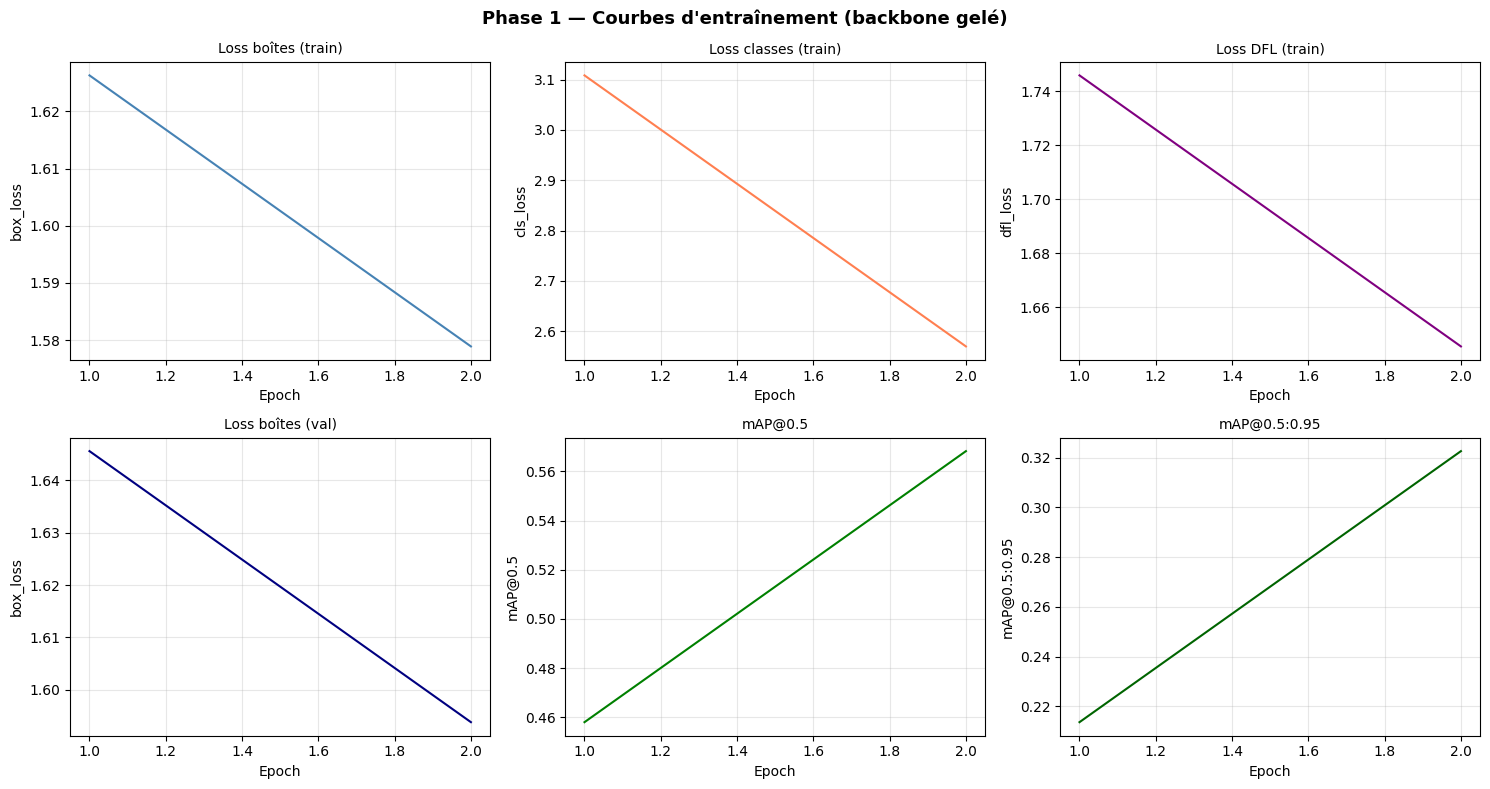

Courbes sauvegardées : ./ppe_project/phase1_curves.png


In [20]:
# Section 4 (suite) — Lecture et affichage des courbes d'entraînement Phase 1

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_CSV = Path('./ppe_project/runs/phase1_freeze10/results.csv')

if RESULTS_CSV.exists():
    df = pd.read_csv(RESULTS_CSV)
    df.columns = df.columns.str.strip()  # Nettoyer les espaces

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Phase 1 — Courbes d\'entraînement (backbone gelé)', fontsize=13, fontweight='bold')

    def plot_metric(ax, col, title, color='steelblue', ylabel=''):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=1.5)
            ax.set_title(title, fontsize=10)
            ax.set_xlabel('Epoch')
            ax.set_ylabel(ylabel or col)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f'Colonne\n{col}\nnon trouvée', ha='center', va='center')
            ax.set_title(title)

    plot_metric(axes[0,0], 'train/box_loss',        'Loss boîtes (train)',    'steelblue', 'box_loss')
    plot_metric(axes[0,1], 'train/cls_loss',        'Loss classes (train)',   'coral',     'cls_loss')
    plot_metric(axes[0,2], 'train/dfl_loss',        'Loss DFL (train)',       'purple',    'dfl_loss')
    plot_metric(axes[1,0], 'val/box_loss',          'Loss boîtes (val)',      'navy',      'box_loss')
    plot_metric(axes[1,1], 'metrics/mAP50(B)',      'mAP@0.5',                'green',     'mAP@0.5')
    plot_metric(axes[1,2], 'metrics/mAP50-95(B)',   'mAP@0.5:0.95',          'darkgreen', 'mAP@0.5:0.95')

    plt.tight_layout()
    plt.savefig('./ppe_project/phase1_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Courbes sauvegardées : ./ppe_project/phase1_curves.png')
else:
    print(f'Fichier results.csv non trouvé : {RESULTS_CSV}')
    print('→ Assurez-vous que la Phase 1 a bien été exécutée.')

---
## Section 5 — Décision : faut-il réentraîner plus de couches ?

### Grille de décision

| Critère | Seuil Phase 2 justifiée | Analyse |
|---|---|---|
| mAP@0.5 global | < 0.70 | Insuffisant pour usage opérationnel |
| AP classe critique | < 0.50 | Classe trop difficile pour le head seul |
| Recall classe sécurité | < 0.60 | Risque de manquer des EPI absents |
| Overfitting (val loss ↑) | Si présent | Arrêter — Phase 2 aggraverait le surapprentissage |
| Dataset trop petit | < 200 images train | Phase 2 → surapprentissage garanti |

> **Règle générale :** si mAP@0.5 Phase 1 < 0.70, la Phase 2 est justifiée.  
> Si mAP@0.5 Phase 1 ≥ 0.75, les résultats sont suffisants — Phase 2 optionnelle.

In [21]:
# Section 5 — Analyse automatique et décision Phase 2

from ultralytics import YOLO
from pathlib import Path

YAML_PATH = Path('./ppe_project/ppe_dataset.yaml')
BEST_P1   = Path('./ppe_project/runs/phase1_freeze10/weights/best.pt')
CLASS_NAMES = ['Mask', 'NO-Mask']

model_dec = YOLO(str(BEST_P1))
metrics   = model_dec.val(data=str(YAML_PATH), split='test', iou=0.5, conf=0.25, verbose=False)

map50     = metrics.box.map50
map5095   = metrics.box.map
ap50_cls  = metrics.box.ap50
rec_cls   = metrics.box.r

# ── Critères de décision ──────────────────────────────────────────────────────
criteres = {
    'mAP@0.5 < 0.70'           : map50 < 0.70,
    'Écart mAP50 - mAP5095 > 0.20' : (map50 - map5095) > 0.20,
    'AP_min classe < 0.50'     : (min(ap50_cls) < 0.50) if len(ap50_cls) > 0 else False,
    'Recall_min < 0.60'        : (min(rec_cls) < 0.60)  if len(rec_cls) > 0  else False,
}

n_ok = sum(criteres.values())

print('ANALYSE DE DÉCISION — PHASE 2')
print('=' * 55)
print(f'  mAP@0.5        : {map50:.4f}')
print(f'  mAP@0.5:0.95   : {map5095:.4f}')
if len(ap50_cls): print(f'  AP min (classe) : {min(ap50_cls):.4f}  ({CLASS_NAMES[ap50_cls.argmin()]})')
if len(rec_cls):  print(f'  Recall min      : {min(rec_cls):.4f}  ({CLASS_NAMES[rec_cls.argmin()]})')
print()
print('Critères déclencheurs de la Phase 2 :')
for critere, atteint in criteres.items():
    statut = '✔ DÉCLENCHÉ' if atteint else '✖ ok'
    print(f'  [{statut}]  {critere}')

print()
print('─' * 55)
if n_ok >= 2:
    print(f'  → DÉCISION : PHASE 2 RECOMMANDÉE ({n_ok}/{len(criteres)} critères déclenchés)')
    print('    Le fine-tuning profond devrait améliorer significativement les résultats.')
    DO_PHASE2 = True
elif n_ok == 1:
    print(f'  → DÉCISION : PHASE 2 OPTIONNELLE ({n_ok}/{len(criteres)} critère déclenché)')
    print('    Amélioration possible mais les résultats sont déjà acceptables.')
    DO_PHASE2 = False
else:
    print(f'  → DÉCISION : PHASE 2 NON NÉCESSAIRE (0/{len(criteres)} critère déclenché)')
    print('    Les résultats de Phase 1 sont suffisants.')
    DO_PHASE2 = False
print('─' * 55)

Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients, 23.3 GFLOPs


val: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\test.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]
'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:13<00:00,  3.35s/it]


                   all         50         92      0.601      0.533      0.594      0.301
Speed: 1.4ms preprocess, 250.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\val2
ANALYSE DE DÉCISION — PHASE 2
  mAP@0.5        : 0.5938
  mAP@0.5:0.95   : 0.3005
  AP min (classe) : 0.5222  (NO-Mask)
  Recall min      : 0.5106  (NO-Mask)

Critères déclencheurs de la Phase 2 :
  [✔ DÉCLENCHÉ]  mAP@0.5 < 0.70
  [✔ DÉCLENCHÉ]  Écart mAP50 - mAP5095 > 0.20
  [✖ ok]  AP_min classe < 0.50
  [✔ DÉCLENCHÉ]  Recall_min < 0.60

───────────────────────────────────────────────────────
  → DÉCISION : PHASE 2 RECOMMANDÉE (3/4 critères déclenchés)
    Le fine-tuning profond devrait améliorer significativement les résultats.
───────────────────────────────────────────────────────


---
## Section 6 — Phase 2 : Fine-tuning profond (toutes les couches)

En Phase 2, **aucune couche n'est gelée** (`freeze` n'est pas passé).  
Toutes les couches, y compris le backbone, s'adaptent aux images hospitalières.

**Point critique :** Le taux d'apprentissage (`lr0`) doit être **10x plus faible** qu'en Phase 1.  
Un LR trop élevé détruirait les poids COCO/ImageNet appris — c'est le **catastrophic forgetting**.

```
Phase 1 : lr0=0.01,  freeze=10  → Head apprend, Backbone stable
Phase 2 : lr0=0.001, freeze=0   → Tout s'adapte doucement
```

In [22]:
# Section 6 — Phase 2 : Fine-tuning toutes couches dégelées
# Exécuter seulement si DO_PHASE2 est True (décision Section 5)

from ultralytics import YOLO
from pathlib import Path

YAML_PATH = Path('./ppe_project/ppe_dataset.yaml')
BEST_P1   = Path('./ppe_project/runs/phase1_freeze10/weights/best.pt')
RUNS_DIR  = Path('./ppe_project/runs')

if not DO_PHASE2:
    print('Phase 2 non déclenchée par l\'analyse (Section 5).')
    print('Modifiez DO_PHASE2 = True pour l\'exécuter manuellement.')
else:
    print('Phase 2 — Fine-tuning profond : toutes les couches dégelées')
    print('Taux d\'apprentissage réduit (lr0=0.001) pour éviter le catastrophic forgetting')
    print('=' * 60)

    # Repartir des meilleurs poids Phase 1
    model_p2 = YOLO(str(BEST_P1))

    results_p2 = model_p2.train(
        data          = str(YAML_PATH),
        epochs        = EPOCHS_P2,            # Epochs supplémentaires
        imgsz         = 640,
        batch         = BATCH,
        lr0           = 0.001,         # LR 10x plus faible qu'en Phase 1
        lrf           = 0.01,
        warmup_epochs = 3,             # Montée en puissance progressive du LR
        weight_decay  = 0.0005,        # Régularisation pour limiter l'overfitting
        # freeze non passé → toutes les couches sont dégelées
        device  = 'cpu',
        project = str(RUNS_DIR),
        name    = 'phase2_full_finetune',
        save    = True,
        plots   = True,
        verbose = True,
    )

    map50_p2   = results_p2.results_dict.get('metrics/mAP50(B)',    0)
    map5095_p2 = results_p2.results_dict.get('metrics/mAP50-95(B)', 0)
    prec_p2    = results_p2.results_dict.get('metrics/precision(B)', 0)
    rec_p2     = results_p2.results_dict.get('metrics/recall(B)',    0)

    print('\n' + '=' * 60)
    print('RÉSULTATS PHASE 2 — TOUTES COUCHES')
    print('=' * 60)
    print(f'  mAP@0.5        : {map50_p2:.4f}')
    print(f'  mAP@0.5:0.95   : {map5095_p2:.4f}')
    print(f'  Précision      : {prec_p2:.4f}')
    print(f'  Recall         : {rec_p2:.4f}')

    BEST_P2 = RUNS_DIR / 'phase2_full_finetune' / 'weights' / 'best.pt'
    print(f'\nMeilleurs poids sauvegardés : {BEST_P2}')

Phase 2 — Fine-tuning profond : toutes les couches dégelées
Taux d'apprentissage réduit (lr0=0.001) pour éviter le catastrophic forgetting
New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
engine\trainer: task=detect, mode=train, model=ppe_project\runs\phase1_freeze10\weights\best.pt, data=ppe_project\ppe_dataset.yaml, epochs=2, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=ppe_project\runs, name=phase2_full_finetune, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, 

train: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\train.cache... 500 images, 0 backgrounds, 0 corrupt: 100%|██████████| 500/500 [00:00<?, ?it/s]
'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
val: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\val.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]

Plotting labels to ppe_project\runs\phase2_full_finetune\labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 63 weight(decay=0.0), 70 weight(decay=0.0005), 69 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to ppe_project\runs\phase2_full_finetune
Starting training for 2 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/2         0G      1.442      2.239      1.539         10        640: 100%|██████████| 125/125 [10:59<00:00,  5.28s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:44<00:00,  3.41s/it]

...

        2/2         0G      1.498      2.218      1.582         11        640: 100%|██████████| 125/125 [11:02<00:00,  5.30s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:39<00:00,  3.03s/it]

                   all        100        172      0.563      0.441      0.506      0.297



2 epochs completed in 0.392 hours.
Optimizer stripped from ppe_project\runs\phase2_full_finetune\weights\last.pt, 19.9MB
Optimizer stripped from ppe_project\runs\phase2_full_finetune\weights\best.pt, 19.9MB

Validating ppe_project\runs\phase2_full_finetune\weights\best.pt...
Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients, 23.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:38<00:00,  2.95s/it]


                   all        100        172      0.558      0.626       0.63      0.317
                  Mask         53        107      0.503      0.776      0.707      0.369
               NO-Mask         52         65      0.613      0.477      0.553      0.266
Speed: 2.4ms preprocess, 344.8ms inference, 0.0ms loss, 13.8ms postprocess per image
Results saved to ppe_project\runs\phase2_full_finetune

RÉSULTATS PHASE 2 — TOUTES COUCHES
  mAP@0.5        : 0.6299
  mAP@0.5:0.95   : 0.3175
  Précision      : 0.5580
  Recall         : 0.6263

Meilleurs poids sauvegardés : ppe_project\runs\phase2_full_finetune\weights\best.pt


---
## Section 7 — Comparaison Phase 1 vs Phase 2 et conclusion

Cette section compare les performances des deux phases et produit un rapport visuel.

In [2]:
# Section 7 — Comparaison complète Phase 1 vs Phase 2

from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

YAML_PATH   = Path('./ppe_project/ppe_dataset.yaml')
BEST_P1     = Path('./ppe_project/runs/phase1_freeze10/weights/best.pt')
BEST_P2     = Path('./ppe_project/runs/phase2_full_finetune/weights/best.pt')
CLASS_NAMES = ['Mask', 'NO-Mask']

# Évaluation des deux modèles
print('Évaluation Phase 1...')
m1 = YOLO(str(BEST_P1)).val(data=str(YAML_PATH), split='test', iou=0.5, conf=0.25, verbose=False)

results_p2_available = BEST_P2.exists()
if results_p2_available:
    print('Évaluation Phase 2...')
    m2 = YOLO(str(BEST_P2)).val(data=str(YAML_PATH), split='test', iou=0.5, conf=0.25, verbose=False)

# ── Tableau comparatif ────────────────────────────────────────────────────────
print('\n' + '=' * 75)
print(f'{"CLASSE":<22} {"AP@0.5 P1":>10} ', end='')
if results_p2_available:
    print(f'{"AP@0.5 P2":>10} {"Gain":>8}')
else:
    print()
print('=' * 75)

for i, name in enumerate(CLASS_NAMES):
    ap1 = m1.box.ap50[i] if i < len(m1.box.ap50) else 0
    print(f'  {name:<20} {ap1:>10.3f} ', end='')
    if results_p2_available:
        ap2  = m2.box.ap50[i] if i < len(m2.box.ap50) else 0
        gain = ap2 - ap1
        signe = '+' if gain >= 0 else ''
        print(f'{ap2:>10.3f} {signe}{gain*100:>6.1f}%')
    else:
        print('(Phase 2 non exécutée)')

print('=' * 75)
print(f'  {"mAP@0.5 global":<20} {m1.box.map50:>10.3f} ', end='')
if results_p2_available:
    gain_map = m2.box.map50 - m1.box.map50
    signe = '+' if gain_map >= 0 else ''
    print(f'{m2.box.map50:>10.3f} {signe}{gain_map*100:>6.1f}%')
else:
    print()

# ── Graphique comparatif ──────────────────────────────────────────────────────
if results_p2_available:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(CLASS_NAMES))
    w = 0.35

    b1 = ax.bar(x - w/2, m1.box.ap50, w, label='Phase 1 (freeze=10)', color='steelblue', alpha=0.85)
    b2 = ax.bar(x + w/2, m2.box.ap50, w, label='Phase 2 (full fine-tune)', color='coral',     alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([n.replace('_', '\n') for n in CLASS_NAMES], fontsize=9)
    ax.set_ylabel('AP@0.5')
    ax.set_ylim(0, 1)
    ax.set_title('Comparaison AP@0.5 par classe — Phase 1 vs Phase 2', fontsize=12, fontweight='bold')
    ax.axhline(y=0.7, color='gray', linestyle=':', linewidth=1, label='Seuil 0.70')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('./ppe_project/comparison_p1_p2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Graphique comparatif sauvegardé : ./ppe_project/comparison_p1_p2.png')

Évaluation Phase 1...
Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients, 23.3 GFLOPs


val: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\test.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]
c:\Users\Luc\anaconda3\envs\yolo_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:16<00:00,  4.09s/it]


                   all         50         92      0.601      0.533      0.594      0.301
Speed: 2.8ms preprocess, 303.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs\detect\val3
Évaluation Phase 2...
Ultralytics 8.3.0  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core(TM) Ultra 5 135U)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients, 23.3 GFLOPs


val: Scanning C:\Users\Luc\Documents\50 MScAIB\53 MSc AIB Certificat-03 Cours & Data\53-02 Méthodes actuelles du DL\TP CNN Détecteur_EPI_YOLOv8\ppe_project\dataset\labels\test.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]
c:\Users\Luc\anaconda3\envs\yolo_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:14<00:00,  3.54s/it]


                   all         50         92      0.628      0.569      0.633      0.334
Speed: 1.2ms preprocess, 263.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs\detect\val4

CLASSE                  AP@0.5 P1  AP@0.5 P2     Gain
  Mask                      0.665      0.706 +   4.0%
  NO-Mask                   0.522      0.560 +   3.8%
  mAP@0.5 global            0.594      0.633 +   3.9%


<Figure size 1200x500 with 1 Axes>

Graphique comparatif sauvegardé : ./ppe_project/comparison_p1_p2.png


In [ ]:
# Section 7 (suite) — Conclusion et récapitulatif final

from pathlib import Path

BEST_P2 = Path('./ppe_project/runs/phase2_full_finetune/weights/best.pt')

print('  RÉCAPITULATIF DU TP — TRANSFER LEARNING EPI HOSPITALIERS')
print('═' * 65)
print()
print('  Modèle de départ   : YOLOv8s (yolov8s.pt)')
print('  Pré-entraîné sur   : COCO (80 classes) + ImageNet backbone')
print('  Classes ajoutées   : 2 classes EPI')
print()
print('  Phase 1 (freeze=10) :')
print(f'    mAP@0.5 = {m1.box.map50:.4f}  |  mAP@0.5:0.95 = {m1.box.map:.4f}')
print(f'    Précision = {m1.box.mp:.4f}  |  Recall = {m1.box.mr:.4f}')
print()

if BEST_P2.exists():
    gain = m2.box.map50 - m1.box.map50
    print('  Phase 2 (full fine-tune) :')
    print(f'    mAP@0.5 = {m2.box.map50:.4f}  |  mAP@0.5:0.95 = {m2.box.map:.4f}')
    print(f'    Précision = {m2.box.mp:.4f}  |  Recall = {m2.box.mr:.4f}')
    print(f'    Gain mAP@0.5 vs Phase 1 : +{gain*100:.1f}%')
    print()
    if gain > 0.05:
        print('  CONCLUSION : La Phase 2 a apporté une amélioration significative (> 5%).')
        print('  Le fine-tuning profond était justifié.')
    else:
        print('  CONCLUSION : La Phase 2 n\'a pas apporté d\'amélioration majeure.')
        print('  La Phase 1 (backbone gelé) était suffisante pour ce dataset.')
else:
    print('  Phase 2 non exécutée.')
    if m1.box.map50 >= 0.70:
        print('  CONCLUSION : La Phase 1 atteint mAP@0.5 ≥ 0.70 — résultats suffisants.')
    else:
        print('  CONCLUSION : Exécuter la Phase 2 (Section 6) pour améliorer les résultats.')

print()
print('═' * 65)
print('  Fichiers produits :')
for f in sorted(Path('./ppe_project').rglob('*.pt')):
    print(f'    {f}')
for f in sorted(Path('./ppe_project').glob('*.png')):
    print(f'    {f}')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  RÉCAPITULATIF DU TP — TRANSFER LEARNING EPI HOSPITALIERS
═════════════════════════════════════════════════════════════════

  Modèle de départ   : YOLOv8s (yolov8s.pt)
  Pré-entraîné sur   : COCO (80 classes) + ImageNet backbone
  Classes ajoutées   : 6 classes EPI hospitalières

  Phase 1 (freeze=10) :
    mAP@0.5 = 0.5938  |  mAP@0.5:0.95 = 0.3005
    Précision = 0.6010  |  Recall = 0.5331

  Phase 2 (full fine-tune) :
    mAP@0.5 = 0.6330  |  mAP@0.5:0.95 = 0.3342
    Précision = 0.6280  |  Recall = 0.5688
    Gain mAP@0.5 vs Phase 1 : +3.9%

  CONCLUSION : La Phase 2 n'a pas apporté d'amélioration majeure.
  La Phase 1 (backbone gelé) était suffisante pour ce dataset.

═════════════════════════════════════════════════════════════════
  Fichiers produits :
    ppe_project\runs\phase1_freeze10\weights\best.pt
    ppe_project\runs\phase1_freeze10\weights\last.pt
    ppe_project\runs\phase2_full_finetune\weights\best.p